# L1 — "Thiếu hụt phục vụ" là gì và vì sao phải nhân với dân số

Notebook này giải thích **một lớp bản đồ duy nhất**, từ đầu, không giả định gì.

---

## Câu hỏi mà L1 tồn tại để trả lời

> **"Nếu chỉ được đặt thêm một trạm sạc ở Hà Nội, đặt ở đâu thì có lợi nhất?"**

Nghe thì hiển nhiên là "đặt ở chỗ xa trạm nhất". Nhưng đó là **câu trả lời sai**, và
notebook này cho thấy vì sao — bằng chính dữ liệu của chúng ta.

---

## Hai quy ước đã chốt, ảnh hưởng trực tiếp tới lớp này

1. **Bỏ trường thời gian, chỉ dùng khoảng cách.** `drive_time_station_min` đứng trên một
   bảng tốc độ giả định (chỉ 1,1% đoạn đường có tag `maxspeed`, và bỏ hẳn tag đi thì kết
   quả gần như không đổi — tức trường đó **100% là giả định**). `dist_station_network_m`
   thì không phụ thuộc giả định nào: nó là **mét đo trên hình học đường thật**.
2. **Trạm 1 súng AC coi như không tồn tại.** Chúng là ổ sạc tại nhà (7–11 kW), không phải
   hạ tầng công cộng. Chúng bị loại khỏi **tập nguồn Dijkstra**, nên khoảng cách phải
   tính lại — không phải chỉ ẩn trên bản đồ.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from scipy.spatial import cKDTree
from scipy.stats import spearmanr

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "analysis"))
import _graph  # noqa: E402

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})

grid = pq.read_table(ROOT / "data/processed/grid_h3_r8.parquet").to_pandas()
com = pq.read_table(ROOT / "data/processed/commune.parquet").to_pandas()
st = pq.read_table(ROOT / "data/processed/stations.parquet").to_pandas()
cell_com = pq.read_table(ROOT / "data/processed/layers/grid_cell_commune.parquet").to_pandas()
print(f"{len(grid):,} ô · {grid.population.sum():,.0f} người · {len(com)} xã/phường")

4,400 ô · 8,831,126 người · 126 xã/phường


## Bước 0 — Tính lại khoảng cách sau khi loại trạm 1 súng AC

Dijkstra đa nguồn trên đồ thị đường bộ OSM (1,33 triệu đỉnh, 2,77 triệu cạnh có hướng),
nguồn là tập trạm **sau khi lọc**. Mất ~15 giây.

In [2]:
G = _graph.build()
tree = cKDTree(np.c_[G["X"], G["Y"]])
cells, ci, cd, clat, clng = _graph.cell_anchors(G, tree)

src = st[st.op_status.isin(["OPERATIONAL", "MAINTENANCE"]) & (st.access != "RESTRICTED")]
src = src[~((src.n_ports == 1) & (src.current_type == "AC"))]
sx, sy = _graph.xy(src.lng.to_numpy(), src.lat.to_numpy())
sd, si = tree.query(np.c_[sx, sy])
ok = sd <= _graph.SNAP_MAX_M
off = pd.Series(sd[ok]).groupby(pd.Series(si[ok])).min()
dn = _graph.multisource(G, G["dist_w"], off.index.to_numpy(np.int32), off.to_numpy())
dd = np.where(cd <= _graph.SNAP_MAX_M, dn[ci], np.inf)

d = pd.DataFrame({"h3_r8": cells, "dist_m": np.where(np.isfinite(dd), dd + cd, np.nan)})
g = grid.merge(d, on="h3_r8", how="left")
print(f"Nguồn: {int(ok.sum()):,} trạm (đã lọc, đã neo được vào mạng đường)")
print(f"Khoảng cách tới trạm gần nhất — trung vị {g.dist_m.median():,.0f} m · "
      f"p90 {g.dist_m.quantile(0.9):,.0f} m · không tới được {g.dist_m.isna().sum()} ô")

Nguồn: 886 trạm (đã lọc, đã neo được vào mạng đường)
Khoảng cách tới trạm gần nhất — trung vị 2,306 m · p90 4,828 m · không tới được 50 ô


---
# Phần 1 — Vì sao bản đồ khoảng cách đơn thuần là bản đồ SAI

Hãy vẽ nó ra và nhìn thẳng vào vấn đề.

In [3]:
far = g.nlargest(12, "dist_m")[["h3_r8", "commune_name", "population", "dist_m", "built_frac"]]
far = far.assign(dist_km=far.dist_m / 1000).drop(columns="dist_m")
print("12 ô XA TRẠM NHẤT Hà Nội:\n")
display(far.round(2))
print(f"\nTổng dân số của 12 ô này: {far.population.sum():,.0f} người")
print(f"Trung vị dân số toàn Hà Nội mỗi ô: {g.population.median():,.0f} người")

12 ô XA TRẠM NHẤT Hà Nội:



,h3_r8,commune_name,population,built_frac,dist_km
2103,88415ca251fffff,Xã Phù Đổng,118.41,0.15,21.16
4046,88415dd4c3fffff,Xã Ba Vì,0.00,0.00,14.66
4058,88415dd4ddfffff,Xã Ba Vì,0.00,0.00,14.58
4052,88415dd4d1fffff,Xã Ba Vì,0.00,0.00,14.39
4055,88415dd4d7fffff,Xã Ba Vì,2.27,0.00,13.69
4054,88415dd4d5fffff,Xã Ba Vì,6.12,0.00,13.68
2711,88415cae43fffff,Xã Sóc Sơn,1103.82,0.23,13.09
4225,88415dd6a1fffff,Xã Yên Bài,0.56,0.00,12.91
4022,88415dd48bfffff,Xã Ba Vì,12.49,0.00,12.39
4021,88415dd489fffff,Xã Ba Vì,0.00,0.00,12.37



Tổng dân số của 12 ô này: 1,244 người
Trung vị dân số toàn Hà Nội mỗi ô: 767 người


Đây là vấn đề, phát biểu bằng một câu:

> **Những ô "thiếu phục vụ nhất" theo khoảng cách là những ô gần như không có ai ở.**

Chúng là núi Ba Vì, bãi giữa sông Hồng, ruộng Mỹ Đức, rừng Sóc Sơn. Đặt một trạm sạc ở đó
sẽ cải thiện con số trên bản đồ rất nhiều, và phục vụ gần như không ai.

Bản đồ khoảng cách đơn thuần **tô đỏ đậm nhất ở đúng chỗ ít đáng quan tâm nhất**. Nó
không sai về mặt số học — nó trả lời đúng câu hỏi *"ô nào xa trạm nhất"*. Nhưng đó không
phải câu hỏi ta cần trả lời.

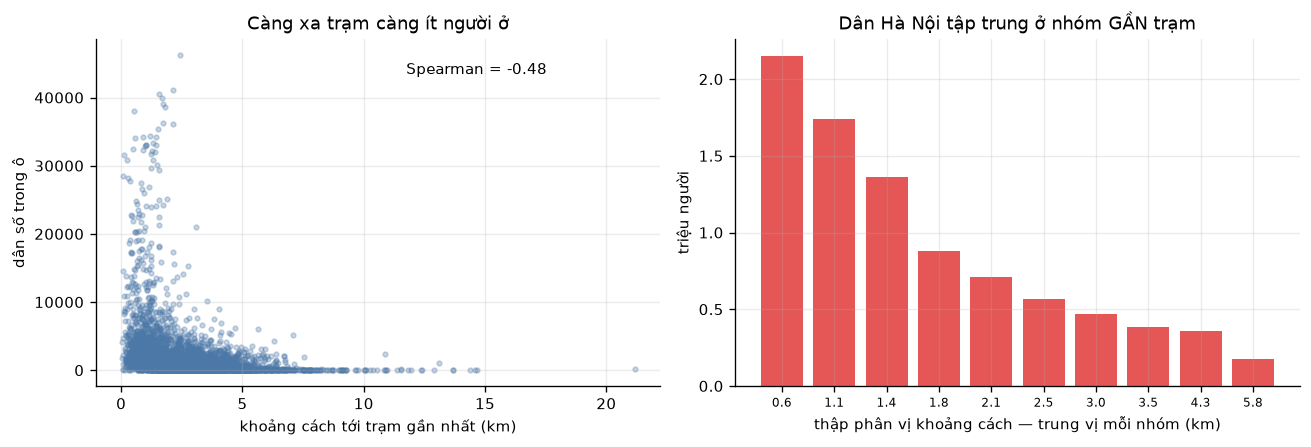

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].scatter(g.dist_m / 1000, g.population, s=8, alpha=0.3, color="#4C78A8")
ax[0].set_xlabel("khoảng cách tới trạm gần nhất (km)")
ax[0].set_ylabel("dân số trong ô")
ax[0].set_title("Càng xa trạm càng ít người ở")
r = spearmanr(g.dist_m.dropna(), g.population[g.dist_m.notna()])
ax[0].annotate(f"Spearman = {r.statistic:.2f}", (0.55, 0.9), xycoords="axes fraction", fontsize=9)

q = pd.qcut(g.dist_m, 10, labels=False, duplicates="drop")
by = g.groupby(q).agg(dan=("population", "sum"), dist=("dist_m", "median"))
ax[1].bar(range(len(by)), by.dan / 1e6, color="#E45756")
ax[1].set_xticks(range(len(by)))
ax[1].set_xticklabels([f"{v/1000:.1f}" for v in by.dist], fontsize=7)
ax[1].set_xlabel("thập phân vị khoảng cách — trung vị mỗi nhóm (km)")
ax[1].set_ylabel("triệu người")
ax[1].set_title("Dân Hà Nội tập trung ở nhóm GẦN trạm")
plt.tight_layout(); plt.show()

Spearman(khoảng cách, dân số) là **âm mạnh**. Đây không phải trùng hợp — đó chính là hệ
quả của việc trạm được đặt ở nơi có người. Nhưng nó khiến bản đồ khoảng cách trở thành
gần như **bản đồ ngược của bản đồ dân cư**.

---
# Phần 2 — Phép sửa: nhân với dân số

## Ý tưởng, bằng một câu đời thường

> Đừng hỏi *"ô này xa bao nhiêu"*. Hỏi *"**tổng quãng đường mà toàn bộ người sống trong ô
> này phải đi** để tới trạm gần nhất là bao nhiêu"*.

```
thiếu_hụt = dân_số × khoảng_cách_tới_trạm_gần_nhất
```

Đơn vị: **người-km**. Đọc là: *"nếu mỗi cư dân trong ô đi một lượt tới trạm gần nhất, tổng
quãng đường cộng lại là bao nhiêu km."*

## Ví dụ bằng số thật

In [5]:
ex_far = g.loc[g[g.population > 20].dist_m.idxmax()]
ex_dense = g[(g.population > g.population.quantile(0.98))].nlargest(1, "dist_m").iloc[0]
rows = []
for lab, r in [("ô ven đô, xa trạm", ex_far), ("ô nội thành, đông dân", ex_dense)]:
    rows.append({
        "ô": lab,
        "xã/phường": r.commune_name,
        "dân số": r.population,
        "khoảng cách (km)": r.dist_m / 1000,
        "người-km": r.population * r.dist_m / 1000,
    })
display(pd.DataFrame(rows).set_index("ô").round(1))

a, b = rows[0], rows[1]
print(f"\nÔ ven đô xa gấp {a['khoảng cách (km)']/b['khoảng cách (km)']:.1f} lần.")
print(f"Nhưng ô nội thành có tổng gánh nặng lớn gấp {b['người-km']/a['người-km']:.1f} lần,")
print("vì nó đông dân hơn rất nhiều lần.")

,xã/phường,dân số,khoảng cách (km),người-km
ô,,,,
"ô ven đô, xa trạm",Xã Phù Đổng,118.4,21.2,2505.8
"ô nội thành, đông dân",Phường Ba Đình,21001.8,3.1,64579.4



Ô ven đô xa gấp 6.9 lần.
Nhưng ô nội thành có tổng gánh nặng lớn gấp 25.8 lần,
vì nó đông dân hơn rất nhiều lần.


## Vì sao phép NHÂN là đúng, không phải phép cộng hay phép chia

Đây là chỗ dễ nhầm nhất, nên nói kỹ.

| Công thức | Nó đo cái gì | Vì sao không dùng |
|---|---|---|
| `khoảng_cách` | bất tiện của **một** người | bỏ qua việc có bao nhiêu người chịu bất tiện đó |
| `dân_số` | quy mô nhu cầu | bỏ qua việc họ đã được phục vụ tốt hay chưa |
| `dân_số + khoảng_cách` | *(vô nghĩa)* | cộng người với mét — hai đơn vị khác nhau |
| `khoảng_cách / dân_số` | *(vô nghĩa)* | ô rỗng sẽ ra vô cùng lớn |
| **`dân_số × khoảng_cách`** | **tổng bất tiện của cả ô** | ✅ |

Lý do sâu hơn: nếu bạn đặt một trạm mới, thứ bạn **thật sự tiết kiệm được** là tổng quãng
đường mà mọi người phải đi. Đó chính là đại lượng người-km. Nên L1 không phải một chỉ số
tuỳ tiện — nó là **đúng đại lượng mà một trạm mới làm giảm đi**.

*(Đây là dạng đơn giản nhất của một họ bài toán quen thuộc trong nghiên cứu vận trù:
p-median — đặt p cơ sở sao cho tổng khoảng cách có trọng số dân là nhỏ nhất.)*

In [6]:
g["nguoi_km"] = g.population * g.dist_m / 1000
print(f"Tổng gánh nặng toàn Hà Nội: {g.nguoi_km.sum():,.0f} người-km")
print(f"Trung bình mỗi người dân:   {g.nguoi_km.sum()/g.population.sum():,.2f} km tới trạm gần nhất")

Tổng gánh nặng toàn Hà Nội: 14,625,482 người-km
Trung bình mỗi người dân:   1.66 km tới trạm gần nhất


---
# Phần 3 — Hai bản đồ khác nhau tới mức nào?

Nếu hai cách xếp hạng cho gần như cùng kết quả thì L1 là công sức thừa. Kiểm.

In [7]:
top_dist = set(g.nlargest(200, "dist_m").h3_r8)
top_pkm = set(g.nlargest(200, "nguoi_km").h3_r8)
ov = len(top_dist & top_pkm)
print(f"Top-200 ô theo KHOẢNG CÁCH và top-200 theo NGƯỜI-KM trùng nhau: {ov}/200 ô ({ov/200:.0%})")
print(f"Spearman giữa hai cách xếp hạng: "
      f"{spearmanr(g.dist_m.fillna(0), g.nguoi_km.fillna(0)).statistic:.3f}\n")

t1 = g.nlargest(8, "dist_m")[["commune_name", "population", "dist_m"]].assign(cach="theo khoảng cách")
t2 = g.nlargest(8, "nguoi_km")[["commune_name", "population", "dist_m"]].assign(cach="theo người-km")
show = pd.concat([t1, t2])
show["km"] = (show.dist_m / 1000).round(2)
display(show.drop(columns="dist_m").set_index(["cach", "commune_name"]).round(0))

Top-200 ô theo KHOẢNG CÁCH và top-200 theo NGƯỜI-KM trùng nhau: 10/200 ô (5%)
Spearman giữa hai cách xếp hạng: -0.085



population    km
cach             commune_name                                    
theo khoảng cách Xã Phù Đổng                          118.0  21.0
                 Xã Ba Vì                               0.0  15.0
                 Xã Ba Vì                               0.0  15.0
                 Xã Ba Vì                               0.0  14.0
                 Xã Ba Vì                               2.0  14.0
                 Xã Ba Vì                               6.0  14.0
                 Xã Sóc Sơn                          1104.0  13.0
                 Xã Yên Bài                             1.0  13.0
theo người-km    Phường Hoàn Kiếm                   46232.0   2.0
                 Phường Văn Miếu - Quốc Tử Giám     41071.0   2.0
                 Phường Ba Đình                     36197.0   2.0
                 Phường Vĩnh Tuy                    38564.0   2.0
                 Phường Bạch Mai                    39076.0   2.0
                 Phường Đống Đa                     39897.0   2.0
                 Phường Ba Đình                     21002.0   3.0
                 Phường Bạch Mai                    40483.0   2.0

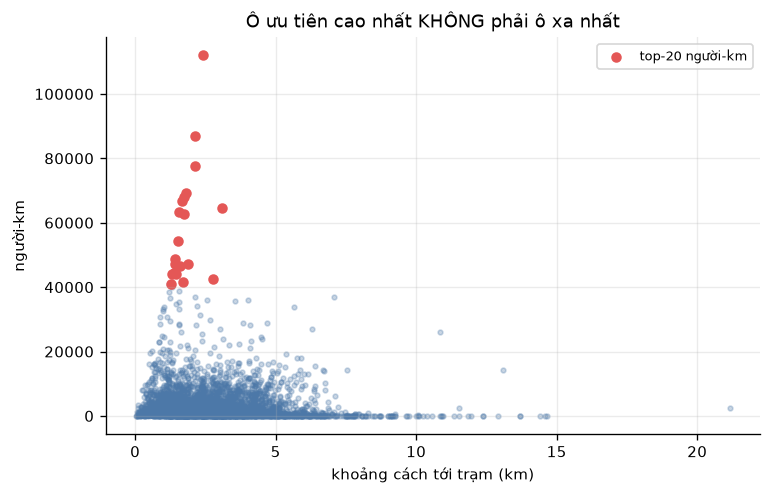

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.scatter(g.dist_m / 1000, g.nguoi_km, s=8, alpha=0.3, color="#4C78A8")
sel = g.nlargest(20, "nguoi_km")
ax.scatter(sel.dist_m / 1000, sel.nguoi_km, s=28, color="#E45756", label="top-20 người-km")
ax.set_xlabel("khoảng cách tới trạm (km)"); ax.set_ylabel("người-km")
ax.set_title("Ô ưu tiên cao nhất KHÔNG phải ô xa nhất")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

Hai danh sách **gần như không giao nhau**. Đây là bằng chứng L1 không phải trang trí — nó
đưa ra một tập ưu tiên **hoàn toàn khác** với bản đồ khoảng cách.

Và tập của L1 là tập đúng: các ô đứng đầu đều là ô đông dân ở vành đai đang đô thị hoá,
không phải ô rỗng ở núi.

---
# Phần 4 — Cộng lên cấp xã/phường (bảng đi kèm bản đồ)

Đây là sản phẩm dùng được nhất của L1: một bảng xếp hạng có thể đọc thành lời.

**Lưu ý kỹ thuật quan trọng:** không dùng nhãn `commune_code` của ô để cộng dồn. 600/4.427
ô có `commune_area_frac < 0,6`, nghĩa là nhãn đó chỉ là "xã chiếm phần lớn nhất", và ô
thực sự nằm trên hai ba xã. Dùng `layers/grid_cell_commune.parquet` — ma trận ô × xã đầy
đủ (6.257 cặp) — để chia đúng theo tỉ lệ diện tích.

In [9]:
cc = cell_com.merge(g[["h3_r8", "nguoi_km", "population", "dist_m"]], on="h3_r8", how="left")
wcol = next(c for c in cc.columns if "frac" in c.lower() or "share" in c.lower())
cc["w"] = cc[wcol]
agg = cc.groupby("commune_code").apply(
    lambda x: pd.Series({
        "nguoi_km": np.nansum(x.nguoi_km * x.w),
        "dan": np.nansum(x.population * x.w),
    }), include_groups=False)

C = com.set_index("commune_code").join(agg)
C["km_binh_quan_moi_nguoi"] = C.nguoi_km / C.dan
C["loai"] = np.where(C.commune_name.str.startswith("Phường"), "Phường", "Xã")

top = C.nlargest(15, "nguoi_km")[
    ["commune_name", "loai", "population", "n_ports", "nguoi_km", "km_binh_quan_moi_nguoi"]
]
print("15 xã/phường có TỔNG GÁNH NẶNG lớn nhất:\n")
display(top.reset_index(drop=True).round(2))

15 xã/phường có TỔNG GÁNH NẶNG lớn nhất:



,commune_name,loai,population,n_ports,nguoi_km,km_binh_quan_moi_nguoi
0,Xã Cổ Đô,Xã,70706.0,6,287389.60,4.09
1,Xã Ứng Hòa,Xã,63750.0,2,246485.48,4.05
2,Xã Tây Phương,Xã,99874.0,59,222498.21,2.22
3,Phường Hồng Hà,Phường,123282.0,34,217446.05,1.64
4,Xã Ô Diên,Xã,97506.0,32,215487.57,2.20
5,Xã Đông Anh,Xã,118183.0,356,214569.30,1.73
6,Xã Phúc Lộc,Xã,61457.0,2,214286.97,3.54
7,Xã Phú Xuyên,Xã,96635.0,51,214239.88,2.18
8,Phường Bạch Mai,Phường,129571.0,0,202321.69,1.54
9,Xã Phượng Dực,Xã,60281.0,2,193750.40,3.31


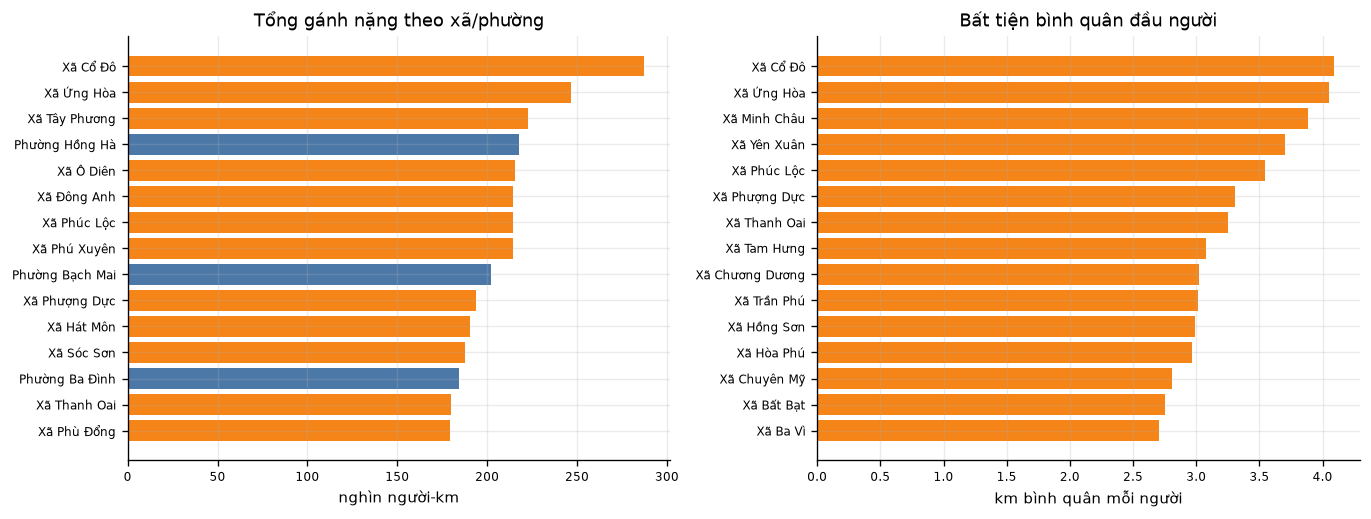

xanh = Phường (đô thị) · cam = Xã (nông thôn), theo phân loại hành chính chính thức


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.4))
t = C.nlargest(15, "nguoi_km").iloc[::-1]
cols = ["#4C78A8" if k == "Phường" else "#F58518" for k in t.loai]
ax[0].barh(t.commune_name, t.nguoi_km / 1000, color=cols)
ax[0].set_xlabel("nghìn người-km"); ax[0].set_title("Tổng gánh nặng theo xã/phường")
ax[0].tick_params(labelsize=7)

t2 = C.nlargest(15, "km_binh_quan_moi_nguoi").iloc[::-1]
cols2 = ["#4C78A8" if k == "Phường" else "#F58518" for k in t2.loai]
ax[1].barh(t2.commune_name, t2.km_binh_quan_moi_nguoi, color=cols2)
ax[1].set_xlabel("km bình quân mỗi người"); ax[1].set_title("Bất tiện bình quân đầu người")
ax[1].tick_params(labelsize=7)
plt.tight_layout(); plt.show()
print("xanh = Phường (đô thị) · cam = Xã (nông thôn), theo phân loại hành chính chính thức")

## Hai bảng này trả lời hai câu hỏi khác nhau — đừng lẫn

| Bảng | Câu hỏi | Dùng khi nào |
|---|---|---|
| **Tổng người-km** | *"Đặt trạm ở đâu thì tổng lợi ích lớn nhất?"* | phân bổ ngân sách, chọn thứ tự triển khai |
| **km bình quân đầu người** | *"Người dân ở đâu đang chịu thiệt nhất?"* | câu hỏi công bằng, phủ dịch vụ tối thiểu |

Bảng đầu sẽ luôn ưu ái phường đông dân. Bảng sau sẽ luôn ưu ái xã xa. **Cả hai đều đúng**,
vì chúng hỏi hai câu khác nhau. Bản đồ nên cho phép đổi giữa hai chế độ, và **ghi rõ đang
ở chế độ nào** — đây chính là hai tiêu chí Phường/Xã mà bạn muốn phân tích.

---
# Phần 5 — Lớp này tin được tới đâu?

Dân số trong ô là **ước lượng WorldPop**, không phải số đếm. Tổng mỗi xã thì chính xác
(neo theo `danso` VNSDI), nhưng phân bố **bên trong** xã là mô hình.

Phép kiểm: giữ nguyên neo tổng từng xã, **thay hẳn bề mặt phân bố**, xem xếp hạng đổi bao
nhiêu. Nếu WorldPop sai hình dạng nghiêm trọng, kết quả sẽ nhảy.

In [11]:
alts = {
    "diện tích đã xây dựng": g.built_frac * g.area_km2 * g.area_frac,
    "chiều dài đường": g.road_len_m * g.area_frac,
    "(đối chứng SAI) rải đều": g.area_km2 * g.area_frac,
}
tot = g.groupby("commune_code").population.transform("sum")
rows = []
for lab, w in alts.items():
    w = w.clip(lower=0)
    s = w.groupby(g.commune_code).transform("sum")
    p_alt = np.where(s > 0, w / s, 0) * tot
    nk = p_alt * g.dist_m / 1000
    m = g.nguoi_km.notna() & pd.Series(nk).notna()
    ia = set(np.argsort(-np.nan_to_num(nk))[:200])
    ib = set(np.argsort(-np.nan_to_num(g.nguoi_km))[:200])
    ca = pd.Series(nk).groupby(g.commune_code).sum()
    cb = g.nguoi_km.groupby(g.commune_code).sum()
    rows.append({
        "bề mặt thay thế": lab,
        "Spearman ô": spearmanr(nk[m], g.nguoi_km[m]).statistic,
        "giữ top-200 ô": len(ia & ib) / 200,
        "Spearman xã": spearmanr(ca, cb).statistic,
        "giữ top-20 xã": len(set(ca.nlargest(20).index) & set(cb.nlargest(20).index)) / 20,
    })
display(pd.DataFrame(rows).set_index("bề mặt thay thế").round(3))

,Spearman ô,giữ top-200 ô,Spearman xã,giữ top-20 xã
bề mặt thay thế,,,,
diện tích đã xây dựng,0.941,0.800,0.990,0.95
chiều dài đường,0.822,0.690,0.985,0.90
(đối chứng SAI) rải đều,0.415,0.505,0.937,0.90


**Cách đọc bảng này.** Dòng cuối là **đối chứng âm** — một bề mặt chắc chắn sai (rải dân
đều khắp xã). Nó sập xuống rõ rệt, chứng minh phép kiểm **có sức phân biệt**: nếu WorldPop
sai hình dạng nghiêm trọng, ta đã nhìn thấy.

Hai dòng trên **không sập**. Kết luận theo hai mức:

- **Cấp xã: rất bền.** Bảng xếp hạng xã gần như không phụ thuộc WorldPop — vì tổng mỗi xã
  đã là số chính thức, và cộng dồn lại thì sai số phân bố bên trong triệt tiêu phần lớn.
  → **Công bố tự tin.**
- **Cấp ô: bền ở mức dải, không bền ở mức thứ hạng.** → **Vẽ theo dải phân vị, đừng đánh
  số "ô thiếu hụt số 1, số 2".**

---
# Phần 6 — L1 KHÔNG nói điều gì

Ba câu người xem sẽ tự động suy ra, và cả ba đều sai:

**❌ "Ô đứng đầu L1 là chỗ nên đặt trạm."**
L1 nói *chỗ nào đang chịu gánh nặng lớn nhất*, không nói *đặt ở đâu thì giảm được nhiều
nhất*. Hai thứ khác nhau: nếu ô A và ô B cạnh nhau cùng đứng đầu, một trạm đặt giữa hai ô
giải quyết cả hai — L1 không mô hình hoá điều đó. Muốn trả lời câu "đặt ở đâu" thì phải
giải bài toán tối ưu vị trí, và đó là **lớp L6**, không phải L1.

**❌ "Ô màu nhạt là ô ổn."**
Ô rỗng người cũng màu nhạt. Màu nhạt nghĩa là *"tổng gánh nặng nhỏ"*, có thể vì gần trạm,
cũng có thể vì không có ai ở.

**❌ "Người ở ô này phải lái X km để sạc."**
Khoảng cách đo từ **tâm hình học của ô** tới trạm gần nhất, không phải từ nhà từng người.
Ô r8 rộng 0,74 km², nên sai số nội tại cỡ vài trăm mét. Đọc L1 ở mức **dải**, không ở mức
con số lẻ.

---

# Tóm tắt một trang

```
CÔNG THỨC   thiếu_hụt = population × dist_station_network_m
ĐƠN VỊ      người-km (mỗi người đi một lượt tới trạm gần nhất)
VÌ SAO NHÂN đó chính là đại lượng mà một trạm mới làm giảm đi
ĐẦU VÀO     population (WorldPop neo VNSDI) × khoảng cách mạng đường
            (Dijkstra, SAU khi loại trạm 1 súng AC)
KHÔNG DÙNG  drive_time — 100% dựa trên bảng tốc độ giả định
VẼ THẾ NÀO  dải phân vị ở cấp ô; bảng xếp hạng ở cấp xã
HAI CHẾ ĐỘ  tổng người-km (hiệu quả)  ·  km bình quân đầu người (công bằng)
ĐỘ TIN CẬY  cấp xã bền · cấp ô chỉ bền ở mức dải
```